# SEAVEA Introductory Tutorial


The **SEAVEA** (see-vee-uh) Toolkit is an open-source framework that supports **Verification, Validation, and Uncertainty Quantification (VVUQ)** for scientific computing applications. It provides a collection of interoperable tools that help researchers design, execute, and analyse computational experiments at scale, from local machines to High-Performance Computing (HPC) environments.

By combining workflow automation, uncertainty quantification, ensemble execution, and surrogate modelling capabilities, SEAVEA enables researchers to conduct complex simulation studies in a reproducible and efficient manner. The toolkit has been developed to support a wide range of scientific domains, including:

* Climate Science
* Fusion Energy
* Epidemiology
* Migration Modelling
* Aerospace Engineering
* Medicine

<p align="center">
    <img src="image.png" width="70%">
</p>

<p align="center">
    <strong>Figure 1.</strong> High-level architecture of the SEAVEA toolkit showing the interaction between local computing resources, HPC systems, workflow automation, uncertainty quantification, and simulation execution tools.
</p>

Figure 1 provides an overview of the SEAVEA ecosystem and how its components work together to support scientific computing workflows. The architecture is divided into a **Local Processing Environment** (left) and an **HPC Processing Environment** (right).

Within the local environment, researchers define simulation experiments, configure uncertain parameters, and perform uncertainty quantification using tools such as **EasyVVUQ**. **FabSim3** acts as the central workflow automation framework, coordinating simulation execution, managing files, and connecting local resources to remote HPC systems.

For large-scale simulation studies, workflows can be executed on HPC resources using **QCG-PilotJob** or **RADICAL-Pilot**, which efficiently manage large ensembles of simulation tasks within a single HPC allocation. These tasks are then scheduled and executed on the HPC cluster.

The broader SEAVEA ecosystem also includes additional components for surrogate modelling (EasySurrogate, MOGP Emulator), multiscale model coupling (MUSCLE3), uncertainty quantification portals (mUQSA), and visualisation (FUMEplot). These components are included in the architecture diagram to illustrate the full capabilities of SEAVEA; however, they are outside the scope of this introductory tutorial. 

## Components Used in this Tutorial

This tutorial focuses on the workflow formed by **EasyVVUQ**, **FabSim3**, and **QCG-PilotJob**, which together enable researchers to define uncertainty studies, automate simulation execution, and efficiently run large ensembles on local or HPC resources.


| Component        | Description                                                                                                                                              |
| ---------------- | -------------------------------------------------------------------------------------------------------------------------------------------------------- |
| **EasyVVUQ**     | Defines uncertain parameters, generates samples, manages simulation campaigns, and performs uncertainty quantification and sensitivity analysis.         |
| **FabSim3**      | Automates workflow execution, file transfer, and job management across local and HPC systems.                                                            |
| **QCG-PilotJob** | Efficiently executes large ensembles of simulation tasks within a single HPC allocation, reducing scheduler overhead and improving resource utilisation. |

## Environment Set-up Instructions

### Prerequisites

Before running this notebook:

- Create a Python 3.10 virtual environment.
- Install `requirements.txt`.
- Install and configure FabSim3, including creation of `machines_user.yml`.
- Install Flee and the FabFlee plugin.
- Confirm that the Mali configuration is available.

> This notebook uses Bash cells and must be run in Linux, WSL, Git Bash,
> Colab, or a Linux-based Jupyter environment.

### Links

Please refer to the following links for the corresponding components setup to be able to follow this tutorial.

FabSim3 installation (The installation process creates the
required fabsim/deploy/machines_user.yml file) - https://fabsim3.readthedocs.io/en/latest/installation/
<br>
EasyVVUQ installation - https://easyvvuq.readthedocs.io/en/dev/installation.html#id1
<br>
QCG-PilotJob installation - https://qcg-pilotjob.readthedocs.io/en/develop/installation.html
<br>
Flee installation - https://flee.readthedocs.io/en/master/Installation_and_Testing/
<br>
FabFlee Plugin - https://fabsim3.readthedocs.io/en/latest/plugins/


## Tutorial Problem Focus

This tutorial demonstrates how the SEAVEA components work together to support the simulation, validation, uncertainty quantification, and efficient execution of forced-migration models.

The primary demonstration uses the **Mali conflict scenario**, with additional examples from **Burundi, South Sudan, and the Central African Republic**.

The tutorial covers:

- Simulating refugee movements and camp populations using Flee.
- Automating simulation workflows and result collection with FabSim3.
- Comparing predicted camp populations with historical UNHCR data.
- Automatically validating multiple conflict scenarios.
- Investigating uncertain movement assumptions, including `max_move_speed` and `max_walk_speed`.
- Measuring total prediction error.
- Calculating Sobol sensitivity indices with EasyVVUQ.
- Executing simulation ensembles concurrently with QCG-PilotJob.

Together, these components provide an integrated workflow for examining how modelling assumptions affect forced-migration predictions while reducing the effort and computational cost of running large simulation ensembles.

# FabSim3 Introduction

### 1. Verify the configured `machines_user.yml` file

FabSim3 uses this machine-specific file to locate its execution environment, input configurations, and results directories. The following cell checks that it was created during FabSim3 installation.

In [1]:
%%bash
set -e

FABSIM_ROOT="$(cd .. && pwd)/FabSim3"
MACHINES_FILE="$FABSIM_ROOT/fabsim/deploy/machines_user.yml"

if [ ! -f "$MACHINES_FILE" ]; then
    echo "Error: FabSim3 is not configured. Complete the linked installation guide."
    exit 1
fi

echo "FabSim3 configuration found: $MACHINES_FILE"

FabSim3 configuration found: /home/anany/github/FabSim3/fabsim/deploy/machines_user.yml


### 2. Migration Modelling with the FabFlee Plugin

[FabFlee](https://github.com/djgroen/FabFlee) connects FabSim3 to
[Flee](https://flee.readthedocs.io/en/latest/), an agent-based model for
simulating the movement of displaced people between geographical locations.

FabFlee automates the preparation, execution, collection, validation, and
visualisation of Flee simulations. In this tutorial, it is used to run the
Mali conflict scenario and compare simulated refugee-camp populations with
historical UNHCR data.

> FabFlee should be installed before the webinar. The standard FabSim3
> command is:
>
> ```bash
> fabsim localhost install_plugin:FabFlee
> ```
>
> Refer to the setup guide for operating-system-specific instructions.

In [2]:
%%bash
fabsim localhost install_plugin:FabFlee

[loading plugin] FabFlee ...
Error: failed to import settings module flee_vis
<class 'ModuleNotFoundError'>
ModuleNotFoundError("No module named 'flee'")


  File "/home/anany/github/FabSim3/plugins/FabFlee/FabFlee.py", line 1072, in <module>
    from plugins.FabFlee.vis.flee_geo import *
  File "/home/anany/github/FabSim3/plugins/FabFlee/vis/flee_geo.py", line 9, in <module>
    import flee.InputGeography


The FabFlee flee_vis functionalities are not imported as a result.
[Executing task] install_plugin


╭────────────────────────── WARNING ���──────────────────────────╮
│ The FabFlee plugin directory already exists.                 │
│ To keep your previous folder, we rename it to: FabFlee_S4QCF │
╰─────────────────────────────────────────────────���────────────╯


[local] mkdir -p /home/anany/github/FabSim3/plugins
[local] rm -rf /home/anany/github/FabSim3/plugins/FabFlee
[local] git clone https://github.com/djgroen/FabFlee.git '/home/anany/github/FabSim3/plugins/FabFlee'


Cloning into '/home/anany/github/FabSim3/plugins/FabFlee'...
Updating files: 100% (2502/2502), done.


FabFlee plugin installed...
No requirements.txt file found for FabFlee plugin
No additional Python packages were installed for this plugin.
Plugin FabFlee installed successfully.


### 3. Verify Flee and FabFlee

This check confirms that the Flee model and its FabSim3 plugin are available before any simulation is launched.

Expected folder layout (recommended):

```text
parent-folder/
├── SEAVEA-tutorials/
├── FabSim3/
└── flee/
```

The verification cell uses one directory above the notebook working directory (`../`) as the parent folder. If your repositories are stored in a different location, update the paths in the cell accordingly.

In [3]:
%%bash
set -e

ROOT="$(cd .. && pwd)"
FLEE_ROOT="$ROOT/flee"
FABFLEE_ROOT="$ROOT/FabSim3/plugins/FabFlee"

if [ -d "$FLEE_ROOT" ]; then
    echo "Flee found: $FLEE_ROOT"
else
    echo "Flee not found: $FLEE_ROOT"
    exit 1
fi

if [ -d "$FABFLEE_ROOT" ]; then
    echo "FabFlee plugin found: $FABFLEE_ROOT"
else
    echo "FabFlee plugin not found: $FABFLEE_ROOT"
    exit 1
fi

Flee found: /home/anany/github/flee
FabFlee plugin found: /home/anany/github/FabSim3/plugins/FabFlee


### 4. Inspect the Mali Scenario

The Mali configuration contains the migration network, conflict data, camp locations, simulation settings, and historical observations used for validation.

In [4]:
%%bash
set -e

FABSIM_ROOT="$(cd .. && pwd)/FabSim3"

MALI_SCENARIO="mali2012"
MALI_CONFIG="$FABSIM_ROOT/plugins/FabFlee/config_files/$MALI_SCENARIO"

[ -d "$MALI_CONFIG" ] || { echo "Error: Mali configuration was not found at $MALI_CONFIG"; exit 1; }

echo "Mali configuration: $MALI_CONFIG"
find "$MALI_CONFIG" -maxdepth 2 -type f | sed -n '1,20p'

Mali configuration: /home/anany/github/FabSim3/plugins/FabFlee/config_files/mali2012
/home/anany/github/FabSim3/plugins/FabFlee/config_files/mali2012/simsetting.yml
/home/anany/github/FabSim3/plugins/FabFlee/config_files/mali2012/input_csv/demographics_ethnicity.csv
/home/anany/github/FabSim3/plugins/FabFlee/config_files/mali2012/input_csv/closures.csv
/home/anany/github/FabSim3/plugins/FabFlee/config_files/mali2012/input_csv/conflicts.csv
/home/anany/github/FabSim3/plugins/FabFlee/config_files/mali2012/input_csv/locations.csv
/home/anany/github/FabSim3/plugins/FabFlee/config_files/mali2012/input_csv/demographics_gender.csv
/home/anany/github/FabSim3/plugins/FabFlee/config_files/mali2012/input_csv/demographics_age.csv
/home/anany/github/FabSim3/plugins/FabFlee/config_files/mali2012/input_csv/routes.csv
/home/anany/github/FabSim3/plugins/FabFlee/config_files/mali2012/input_csv/sim_period.csv
/home/anany/github/FabSim3/plugins/FabFlee/config_files/mali2012/input_csv/registration_correcti

### 5. Run a Baseline Mali Simulation

There are 4 different ways to execute multiscale migration simulations in FabFlee:

* Single-model execution
<br>
* Ensemble execution
<br>
* Replica execution
<br>
* Coupled execution

Each method has its unique purpose. The single-model execution can be easily performed on a laptop and instantly provide an overview to users. The ensemble execution may be useful for those who run multiple simulation instances simultaneously. The replica execution could be an interesting option for those who run simulations at once with identical inputs for analysis. The coupled execution can couple migration simulation with conflict evolution models in the context of multiscale uncertainty quantification (UQ).

#### Purposes of Demonstration

To execute FabFlee job on a localhost, execute one of the conflict instances using `flee` function in `FabSim3/plugins/FabFlee/config_files`, such as Mali (mali, simulation period of 300 days), Burundi (burundi, simulation period of 396 days), South Sudan (ssudan, simulation period of 604 days) and Central African Republic (car, simulation period of 820 days). 

For illustration purposes, the conflict scenario of Mali is executed to obtain the simulation output for a simulation period of 50 days, which can be changed up to 300 days.

In [5]:
%%bash

fabsim localhost sflee:mali2012,simulation_period=50

[loading plugin] FabFlee ...
Error: failed to import settings module flee_vis
<class 'ModuleNotFoundError'>
ModuleNotFoundError("No module named 'flee'")


  File "/home/anany/github/FabSim3/plugins/FabFlee/FabFlee.py", line 1072, in <module>
    from plugins.FabFlee.vis.flee_geo import *
  File "/home/anany/github/FabSim3/plugins/FabFlee/vis/flee_geo.py", line 9, in <module>
    import flee.InputGeography


The FabFlee flee_vis functionalities are not imported as a result.
[Executing task] sflee
calling task sflee from plugin FabFlee

NO machines_FabFlee_user.yml FOUND

[local] ssh -Y -p 22 anany@localhost 'mkdir -p /home/anany/github/FabSim3/localhost_exe/FabSim/config_files; mkdir -p /home/anany/github/FabSim3/localhost_exe/FabSim/results; mkdir -p /home/anany/github/FabSim3/localhost_exe/FabSim/scripts; mkdir -p /home/anany/github/FabSim3/localhost_exe/FabSim/config_files/mali2012'


[local] rsync -pthrvz /home/anany/github/FabSim3/plugins/FabFlee/config_files/mali2012/ anany@localhost:/home/anany/github/FabSim3/localhost_exe/FabSim/config_files/mali2012/
sending incremental file list
./
acled.csv
run_UNHCR_uncertainty.py
simsetting.yml
example_sweepdir/
example_sweepdir/100/
example_sweepdir/100/simsetting.csv
example_sweepdir/200/
example_sweepdir/200/simsetting.csv
example_sweepdir/400/
example_sweepdir/400/simsetting.csv
input_csv/
input_csv/closures.csv
input_csv/conflicts.csv
input_csv/demographics_age.csv
input_csv/demographics_ethnicity.csv
input_csv/demographics_gender.csv
input_csv/locations.csv
input_csv/registration_corrections.csv
input_csv/routes.csv
input_csv/sim_period.csv
source_data/
source_data/bf-bobo.csv
source_data/bf-goudoubo.csv
source_data/bf-mentao.csv
source_data/bf-ouagadougou.csv
source_data/camp_issues.md
source_data/data_layout.csv
source_data/mau-fassala-mbera.csv
source_data/mau-fassala.csv
source_data/mau-mbera.csv
source_data/nig-

sending incremental file list
acled.csv
run_UNHCR_uncertainty.py
simsetting.yml
example_sweepdir/
example_sweepdir/100/
example_sweepdir/100/simsetting.csv
example_sweepdir/200/
example_sweepdir/200/simsetting.csv
example_sweepdir/400/
example_sweepdir/400/simsetting.csv
input_csv/
input_csv/closures.csv
input_csv/conflicts.csv
input_csv/demographics_age.csv
input_csv/demographics_ethnicity.csv
input_csv/demographics_gender.csv
input_csv/locations.csv
input_csv/registration_corrections.csv
input_csv/routes.csv
input_csv/sim_period.csv
source_data/
source_data/bf-bobo.csv
source_data/bf-goudoubo.csv
source_data/bf-mentao.csv
source_data/bf-ouagadougou.csv
source_data/camp_issues.md
source_data/data_layout.csv
source_data/mau-fassala-mbera.csv
source_data/mau-fassala.csv
source_data/mau-mbera.csv
source_data/nig-abala.csv
source_data/nig-intikane.csv
source_data/nig-mangaize.csv
source_data/nig-niamey.csv
source_data/nig-tabareybarey.csv
source_data/refugees.csv
source_data/religion.csv


YAML file: simsetting.yml
YAML: {'log_levels': {'agent': 1, 'camp': 0, 'init': 0, 'link': 1, 'conflict': 0, 'granularity': 'location'}, 'spawn_rules': {'take_from_population': False, 'conflict_spawn_decay': [1.0, 1.0, 1.0, 0.5, 0.1], 'insert_day0': True}, 'move_rules': {'max_move_speed': 200.0, 'max_walk_speed': 35.0, 'foreign_weight': 1.0, 'camp_weight': 5.0, 'awareness_level': 1, 'capacity_buffer': 0.75, 'conflict_weight': 0.25, 'conflict_movechance': 1.0, 'camp_movechance': 0.001, 'default_movechance': 0.3, 'capacity_scaling': 1.0, 'avoid_short_stints': False, 'start_on_foot': False, 'weight_power': 1.0}, 'optimisations': {'hasten': 10}}
Take from population? False
Spawn decay set to: [1.0, 1.0, 1.0, 0.5, 0.1], with interval 30
INFO: Fixed Route Generation for Locations: False
Move rules set to: {'FloodRulesEnabled': False, 'FloodForecaster': False, 'flood_forecaster_timescale': 0, 'MaxMoveSpeed': 200.0, 'MaxWalkSpeed': 35.0, 'MaxCrossingSpeed': 20.0, 'ForeignWeight': 1.0, 'CampWeig

Use fabsim localhost fetch_results to copy the results back to local machine!
submitted job script = 
['/home/anany/github/FabSim3/localhost_exe/FabSim/results/mali2012_localhost_1/mali2012_localhost_1.sh']


#### Fetching the simulation results to `FabSim3/results` directory

After the job has finished, a message will be printed indicating where the output data resides. To fetch and copy the obtained results to `FabSim3/results` directory, simply execute:

In [6]:
%%bash
fabsim localhost fetch_results

[loading plugin] FabFlee ...
Error: failed to import settings module flee_vis
<class 'ModuleNotFoundError'>
ModuleNotFoundError("No module named 'flee'")


  File "/home/anany/github/FabSim3/plugins/FabFlee/FabFlee.py", line 1072, in <module>
    from plugins.FabFlee.vis.flee_geo import *
  File "/home/anany/github/FabSim3/plugins/FabFlee/vis/flee_geo.py", line 9, in <module>
    import flee.InputGeography


The FabFlee flee_vis functionalities are not imported as a result.
[Executing task] fetch_results
[local] rsync -pthrvz -e 'ssh -p 22' anany@localhost:/home/anany/github/FabSim3/localhost_exe/FabSim/results// /home/anany/github/FabSim3/results/
receiving incremental file list
./
mali2012_localhost_1/
mali2012_localhost_1/acled.csv
mali2012_localhost_1/agents.out.0
mali2012_localhost_1/env.log
mali2012_localhost_1/env.yml
mali2012_localhost_1/links.out.0
mali2012_localhost_1/mali2012_localhost_1.sh
mali2012_localhost_1/out.csv
mali2012_localhost_1/run_UNHCR_uncertainty.py
mali2012_localhost_1/simsetting.yml
mali2012_localhost_1/example_sweepdir/
mali2012_localhost_1/example_sweepdir/100/
mali2012_localhost_1/example_sweepdir/100/simsetting.csv
mali2012_localhost_1/example_sweepdir/200/
mali2012_localhost_1/example_sweepdir/200/simsetting.csv
mali2012_localhost_1/example_sweepdir/400/
mali2012_localhost_1/example_sweepdir/400/simsetting.csv
mali2012_localhost_1/input_csv/
mali2012_localh

### 6. Plotting the simulation output

After fetching the simulation results, analyse and interpret simulation output by plotting graphs for individual camps comparing simulation output and UNHCR data, as well as average relative difference graph for the simulated conflict situation.

In [7]:
%%bash

cd FabSim3

fabsim localhost plot_output:mali2012_localhost_1,out

[loading plugin] FabFlee ...
Error: failed to import settings module flee_vis
<class 'ModuleNotFoundError'>
ModuleNotFoundError("No module named 'flee'")


  File "/home/anany/github/FabSim3/plugins/FabFlee/FabFlee.py", line 1072, in <module>
    from plugins.FabFlee.vis.flee_geo import *
  File "/home/anany/github/FabSim3/plugins/FabFlee/vis/flee_geo.py", line 9, in <module>
    import flee.InputGeography


The FabFlee flee_vis functionalities are not imported as a result.
[Executing task] plot_output
calling task plot_output from plugin FabFlee

NO machines_FabFlee_user.yml FOUND

[local] mkdir -p /home/anany/github/FabSim3/results/mali2012_localhost_1/out
mali2012 - single-scale model: Averaged error normal:  0.45337807070374053 , rescaled:  0.2874326468426883 , len:  50
The results of Serial mode simulation are stored in /home/anany/github/FabSim3/results/mali2012_localhost_1/out directory.


To list generated plots, run the following command

In [8]:
%%bash
RESULT_DIR=$(ls -dt /home/anany/github/FabSim3/results/mali2012_localhost_* | head -n 1)

echo "Latest result: $RESULT_DIR"
find "$RESULT_DIR/out" -maxdepth 1 -type f

Latest result: /home/anany/github/FabSim3/results/mali2012_localhost_1


In [ ]:
%%bash
RESULT_DIR=$(find /home/anany/github/FabSim3/results \
  -maxdepth 1 -type d -name "mali2012_localhost_*" \
  -printf "%T@ %p\n" | sort -nr | head -n 1 | cut -d" " -f2-)

echo "Result directory: $RESULT_DIR"
echo "Output contents:"
find "$RESULT_DIR/out" -type f

To view generated plots, simply run:

In [ ]:
from IPython.display import Image 
Image('/home/anany/github/FabSim3/results/mali2012_localhost_1/out/camps/Abala.png') ## CHANGE TO GENERIC ONE

### 7. Compare Predictions with UNHCR Data

FabFlee compares simulated populations at individual camps with historical UNHCR observations. The generated plots show camp-level agreement and prediction error over time.

In [ ]:
%%bash
set -e

export MPLBACKEND=Agg

FABSIM_ROOT="$(cd .. && pwd)/FabSim3"
FABSIM_PYTHON="$FABSIM_ROOT/VirtualEnv/bin/python"

LATEST_RESULT=$(
    find "$FABSIM_ROOT/results" \
        -maxdepth 1 \
        -type d \
        -name "mali2012_localhost_*" \
        ! -name "*_SA_*" \
        -printf "%T@ %p\n" |
    sort -nr |
    head -n 1 |
    cut -d" " -f2-
)

if [ -z "$LATEST_RESULT" ]; then
    echo "No fetched Mali result found. Run and fetch the baseline first."
    exit 1
fi

RUN_NAME="$(basename "$LATEST_RESULT")"

cd "$FABSIM_ROOT"

echo "Generating validation plots for: $RUN_NAME"

"$FABSIM_PYTHON" -X utf8 ./fabsim/bin/fabsim \
    localhost "plot_output:${RUN_NAME},out"

In [ ]:
from pathlib import Path
from IPython.display import Image, display

fabsim_root = (Path.cwd().parent / "FabSim3").resolve()

result_directories = sorted(
    [
        path
        for path in (fabsim_root / "results").glob(
            "mali2012_localhost_*"
        )
        if "_SA_" not in path.name
    ],
    key=lambda path: path.stat().st_mtime,
    reverse=True,
)

if not result_directories:
    raise FileNotFoundError(
        "No fetched Mali result found. Run the baseline simulation first."
    )

result_directory = result_directories[0]
plot_directory = result_directory / "out"

print(f"Validation results: {result_directory.name}\n")

# Display two representative camp comparisons.
camp_plots = sorted((plot_directory / "camps").glob("*.png"))

for plot in camp_plots[:2]:
    print(f"Camp comparison: {plot.stem}")
    display(Image(filename=str(plot)))

# Display aggregate prediction-error plots.
error_plots = [
    plot_directory / "errors" / "error_comparison.png",
    plot_directory / "errors" / "error.png",
]

for plot in error_plots:
    if plot.is_file():
        print(f"Error analysis: {plot.name}")
        display(Image(filename=str(plot)))

# EasyVVUQ Introduction

[EasyVVUQ](https://easyvvuq.readthedocs.io/) is a Python library that simplifies **Uncertainty Quantification (UQ)** and **Sensitivity Analysis (SA)** for scientific simulations. It provides a user-friendly interface for defining uncertain parameters, generating samples, executing simulation campaigns, and analysing results.

### Key Capabilities

- **Parameter Definition**: Specify uncertain input parameters and their probability distributions.
- **Sampling**: Generate parameter samples using various methods (Monte Carlo, Latin Hypercube, Polynomial Chaos, etc.).
- **Campaign Management**: Organize and execute simulation ensembles systematically.
- **Sensitivity Analysis**: Calculate Sobol indices and other sensitivity measures to identify which uncertain parameters most significantly affect model outputs.
- **Uncertainty Quantification**: Compute statistical moments and probability distributions of model predictions.

### Role in SEAVEA Workflow

In this tutorial, EasyVVUQ works with FabSim3 and FabFlee to:

1. Define uncertain Flee parameters such as `max_move_speed` and `max_walk_speed`.
2. Generate parameter samples using polynomial chaos expansion.
3. Create a simulation campaign with one Flee run per sample.
4. Analyse the ensemble results to calculate how parameter uncertainty propagates to prediction error.

This integrated approach enables researchers to understand the sensitivity of forced-migration predictions to modelling assumptions without manually configuring hundreds of individual simulations.

### EasyVVUQ Components

EasyVVUQ works through a series of interconnected components that manage the uncertainty quantification workflow. Each component plays a specific role in transforming uncertain parameters into actionable insights about simulation sensitivity.

| Component | What it means | Your FLEE example |
| --- | --- | --- |
| **Parameter distributions** | Define uncertain inputs | `max_move_speed`, `max_walk_speed` |
| **Sampler** | Chooses parameter combinations | Different speed values to test |
| **Encoder** | Writes parameter values into input files | Creates FLEE input/config file |
| **Decoder** | Reads simulation output | Extracts total error / camp population |
| **Analysis** | Interprets results | Sobol sensitivity indices |

### Workflow Overview

1. **Parameter Distributions**: You specify which input parameters are uncertain and their probability distributions (e.g., `max_move_speed` ranges from 2 to 4 km/day).

2. **Sampler**: EasyVVUQ generates parameter samples using methods such as Polynomial Chaos Expansion, Monte Carlo, or Latin Hypercube Sampling. Each sample represents a unique combination of uncertain parameters.

3. **Encoder**: For each sample, the encoder converts parameter values into FLEE-compatible input files and configuration settings.

4. **Simulation Execution**: FLEE runs with each encoded parameter set, producing camp population time series and other outputs.

5. **Decoder**: After simulation, the decoder extracts relevant outputs (e.g., total prediction error, camp populations) from FLEE results.

6. **Analysis**: Statistical methods compute sensitivity indices (Sobol indices), uncertainty bounds, and other measures that quantify how parameter uncertainty propagates to model predictions.

This modular design allows EasyVVUQ to work with any simulation tool by simply changing the encoder and decoder while keeping the sampling and analysis components generic.

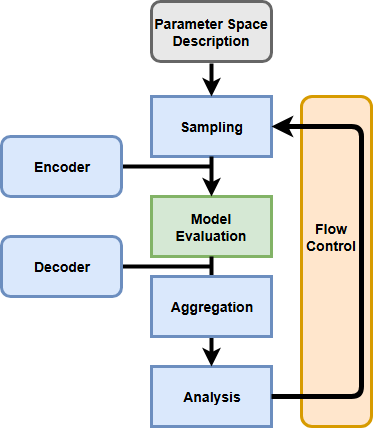

#### 1. Install EasyVVUQ into FabSim3’s environment
The notebook launches FabSim3 using its own interpreter, so EasyVVUQ must exist there:

In [ ]:
%%bash
../FabSim3/VirtualEnv/bin/python -m pip install easyvvuq==1.3 chaospy

### 7. Importing EasyVVUQ and Chaospy

**EasyVVUQ** is the core library for uncertainty quantification and sensitivity analysis. It provides the tools to define parameter distributions, manage sampling campaigns, and calculate sensitivity indices like Sobol indices.

**Chaospy** is a polynomial chaos expansion library that EasyVVUQ uses for advanced sampling and uncertainty propagation. It enables efficient parameter sampling and surrogate modelling through polynomial chaos methods.

Together, these libraries enable the automated generation of parameter samples and the statistical analysis of how uncertain inputs propagate through the Flee migration model.

In [ ]:
import easyvvuq as uq
import chaospy as cp

### 8. Read the Real FabFlee Uncertainty Configuration

The uncertain parameters are defined in FabFlee’s `flee_SA_config.yml` file. This is the same configuration used by the real EasyVVUQ sensitivity-analysis workflow.

The cell below reads the selected parameters and their ranges directly from that file. This ensures that the parameter values displayed in the notebook match those used to generate and execute the Flee simulation ensemble.

In [ ]:
from pathlib import Path
import yaml

fabsim_root = (Path.cwd().parent / "FabSim3").resolve()
sa_config_file = (
    fabsim_root
    / "plugins"
    / "FabFlee"
    / "SA"
    / "flee_SA_config.yml"
)

with sa_config_file.open(encoding="utf-8") as stream:
    sa_config = yaml.safe_load(stream)

flee_parameters = {}

for name in sa_config["selected_vary_parameters"]:
    lower, upper = sa_config["vary_parameters_range"][name]["range"]
    flee_parameters[name] = {
        "min": lower,
        "max": upper,
        "unit": "km/day",
    }

print(f"Configuration: {sa_config_file}")

for name, spec in flee_parameters.items():
    print(
        f"{name}: Uniform({spec['min']}, {spec['max']}) "
        f"{spec['unit']}"
    )

##### Parameter Exploration

To perform sensitivity analysis on input parameters of Flee, we mainly focus on two sampler examples, namely (a) SCSampler (Stochastic Collocation sampler) and (b) PCESampler (Polynomial Chaos Expansion sampler), that are available in EasyVVUQ. The configuration for SA can be set in `flee_SA_config.yml` located in `FabSim3/plugin/FabFlee` directory. All required configurations for FabFlee SA, such as sampler name, varying input parameters, and the number of polynomial order, are loaded from `flee_SA_config.yml` file. To illustrate, we present an example of two `config` parameters below, namely (`max_move_speed` and `max_walk_speed`):


In [ ]:
from pathlib import Path
import yaml

config_path = (
    Path.cwd().parent
    / "FabSim3"
    / "plugins"
    / "FabFlee"
    / "SA"
    / "flee_SA_config.yml"
)

with config_path.open(encoding="utf-8") as file:
    flee_sa_config = yaml.safe_load(file)

summary = {
    "selected_vary_parameters":
        flee_sa_config["selected_vary_parameters"],
    "distribution_type":
        flee_sa_config["distribution_type"],
    "polynomial_order":
        flee_sa_config["polynomial_order"],
    "sampler_name":
        flee_sa_config["sampler_name"],
}

print(yaml.safe_dump(summary, sort_keys=False))

### 9. Create the Chaospy Distributions

EasyVVUQ uses Chaospy distributions to represent uncertain inputs. The distributions below are created from the parameter ranges read from FabFlee’s real sensitivity-analysis configuration.

These distributions will be passed to the EasyVVUQ sampler in the next step.

In [ ]:
distribution_type = sa_config["distribution_type"]

if distribution_type == "Uniform":
    distribution_class = cp.Uniform
elif distribution_type == "DiscreteUniform":
    distribution_class = cp.DiscreteUniform
else:
    raise ValueError(f"Unsupported distribution: {distribution_type}")

vary = {
    name: distribution_class(spec["min"], spec["max"])
    for name, spec in flee_parameters.items()
}

vary

### 10. Create the EasyVVUQ Sampler

The sampler chooses the parameter combinations used in the sensitivity study. Its type, polynomial order, and quadrature settings are read from FabFlee’s real configuration.

This cell previews the same sampling strategy that `flee_init_SA` will use when creating the real simulation ensemble.

In [ ]:
sampler_name = sa_config["sampler_name"]

if sampler_name == "SCSampler":
    sampler = uq.sampling.SCSampler(
        vary=vary,
        polynomial_order=sa_config["polynomial_order"],
        quadrature_rule=sa_config["quadrature_rule"],
        growth=sa_config["growth"],
        sparse=sa_config["sparse"],
        midpoint_level1=sa_config["midpoint_level1"],
        dimension_adaptive=sa_config["dimension_adaptive"],
    )

elif sampler_name == "PCESampler":
    sampler = uq.sampling.PCESampler(
        vary=vary,
        polynomial_order=sa_config["polynomial_order"],
        rule=sa_config["quadrature_rule"],
        sparse=sa_config["sparse"],
        growth=sa_config["growth"],
    )

else:
    raise ValueError(f"Unsupported EasyVVUQ sampler: {sampler_name}")

print(f"Sampler: {sampler_name}")
print(f"Polynomial order: {sa_config['polynomial_order']}")
print(sampler)

The following cell displays the parameter combinations generated by the configured sampler. These provide a preview of the samples that FabFlee will regenerate when `flee_init_SA` creates the real EasyVVUQ campaign.

In [ ]:
def clean_sample(sample):
    """
    Convert EasyVVUQ/NumPy values into standard Python values
    so the generated parameter combinations are easy to display.
    """
    return {
        key: value.item() if hasattr(value, "item") else value
        for key, value in sample.items()
    }


preview_parameter_sets = [
    clean_sample(sample)
    for sample in sampler
]

print(
    f"EasyVVUQ generated {len(preview_parameter_sets)} "
    "parameter sets:\n"
)

for index, sample in enumerate(preview_parameter_sets):
    print(f"Sample {index}: {sample}")

### 11. Generate and Execute the Real EasyVVUQ Ensemble

FabFlee’s `flee_init_SA` task creates an EasyVVUQ campaign from the configuration examined above. For each sampled parameter combination, EasyVVUQ generates a `simsetting.yml` file and FabSim3 executes a real Mali Flee simulation.

Each simulation produces an `out.csv` file containing model predictions and the total prediction error. A 30-day simulation period is used to keep the tutorial runtime manageable.

In [ ]:
%%bash
set -e

export MPLBACKEND=Agg

FABSIM_ROOT="$(cd .. && pwd)/FabSim3"
FABSIM_PYTHON="$FABSIM_ROOT/VirtualEnv/bin/python"

if [ ! -x "$FABSIM_PYTHON" ]; then
    echo "FabSim3 Python environment not found: $FABSIM_PYTHON"
    exit 1
fi

cd "$FABSIM_ROOT"

"$FABSIM_PYTHON" -X utf8 ./fabsim/bin/fabsim \
    localhost flee_init_SA:mali2012,simulation_period=30

### 12. Inspect the Encoded Flee Configurations

EasyVVUQ’s `GenericEncoder` creates one `simsetting.yml` file for each sampled parameter combination. FabFlee places these configurations in the Mali `SWEEP` directory before FabSim3 executes the ensemble.

The following cell reads the generated files and displays the movement parameters used by each Flee run. This confirms that the EasyVVUQ samples were passed into the real model.

In [ ]:
from pathlib import Path
import yaml

sweep_dir = (
    fabsim_root
    / "plugins"
    / "FabFlee"
    / "config_files"
    / "mali2012"
    / "SWEEP"
)

simsetting_files = sorted(sweep_dir.glob("run_*/simsetting.yml"))

if not simsetting_files:
    raise FileNotFoundError(
        "No encoded simsetting.yml files were found. "
        "Run Step 11 first."
    )

print(f"Found {len(simsetting_files)} encoded configurations:\n")

selected_parameters = sa_config["selected_vary_parameters"]

for simsetting_file in simsetting_files:
    with simsetting_file.open(encoding="utf-8") as stream:
        settings = yaml.safe_load(stream)

    move_rules = settings["move_rules"]
    sampled_values = {
        parameter: move_rules[parameter]
        for parameter in selected_parameters
    }

    print(f"{simsetting_file.parent.name}: {sampled_values}")

### 13. Decode and Analyse the Real Ensemble Results

FabFlee’s `flee_analyse_SA` task performs the final EasyVVUQ stages. It fetches the `out.csv` file from every Flee run, uses EasyVVUQ’s `SimpleCSV` decoder to extract the `Total error` quantity of interest, and collates the results.

EasyVVUQ then calculates statistical measures and Sobol sensitivity indices. These indices show how strongly each uncertain movement parameter contributes to variation in Flee’s prediction error.

In [ ]:
%%bash
set -e

export MPLBACKEND=Agg

FABSIM_ROOT="$(cd .. && pwd)/FabSim3"
FABSIM_PYTHON="$FABSIM_ROOT/VirtualEnv/bin/python"

if [ ! -x "$FABSIM_PYTHON" ]; then
    echo "FabSim3 Python environment not found: $FABSIM_PYTHON"
    exit 1
fi

cd "$FABSIM_ROOT"

"$FABSIM_PYTHON" -X utf8 ./fabsim/bin/fabsim \
    localhost flee_analyse_SA:mali2012

### 14. Display and Interpret the Sensitivity Results

The analysis produces first-order Sobol indices for each uncertain parameter. A larger index means that the parameter explains a greater proportion of the variation in Flee’s total prediction error.

The cell below reads the generated `sobols.yml` file, displays the mean sensitivity index for each parameter, and shows the plots created by FabFlee.

In [ ]:
from IPython.display import Image, display
import yaml

campaign_dir = (
    fabsim_root
    / "plugins"
    / "FabFlee"
    / "SA"
    / f"flee_SA_{sa_config['sampler_name']}_mali2012"
)

sobols_file = campaign_dir / "sobols.yml"

if not sobols_file.is_file():
    raise FileNotFoundError(
        "Sobol results were not found. Run Step 13 first."
    )

with sobols_file.open(encoding="utf-8") as stream:
    sobol_results = yaml.safe_load(stream)

campaign_info = sobol_results["campaign_info"]

print("Campaign:", campaign_info["name"])
print("Number of runs:", campaign_info["num_runs"])
print("Quantity of interest:", campaign_info["output_column"])
print("\nMean first-order Sobol indices:")

for parameter in sa_config["selected_vary_parameters"]:
    mean_index = sobol_results[parameter]["sobols_first_mean"]
    print(f"  {parameter}: {mean_index:.4f}")

print("\nGenerated analysis plots:")

for plot_file in sorted(campaign_dir.glob("*.png")):
    print(plot_file.name)
    display(Image(filename=str(plot_file)))

# QCG-PilotJob: Scaling the Ensemble

Each EasyVVUQ sample produces an independent Flee simulation. FabSim3 manages the workflow, while QCG-PilotJob can schedule these simulations concurrently within an HPC allocation. This reduces scheduler overhead when sensitivity studies contain hundreds or thousands of runs.

The local EasyVVUQ demonstration above uses FabSim3’s standard ensemble execution. QCG-PilotJob becomes valuable when the same workflow is scaled to systems such as ARCHER2.

In [9]:
ls ~/.ssh

authorized_keys  config  id_rsa  id_rsa.pub  known_hosts  known_hosts.old


In [10]:
cat ~/.ssh/id_rsa.pub

ssh-rsa AAAAB3NzaC1yc2EAAAADAQABAAACAQDpMmFHzJWwpaGLn8WJzbQ3L+3fCeDcuKMBsaIb9xA9B8/sh9m33HiCqj3tLDmLPxtJDRmTvTuHK89N5Mz3YVh+aEdMmvMITR74bvVQANcPHvyW41Vpn9mqAtnd1qwj/XwSUvXkmiOcwQhY1ej5HZWs8rN7QubosAtkyFXnmgdHM5k2J4NlvSZqk/5t9onBXudj6HF/FiLO7E/dfYgrtfDLHgWysACJYpgeTZv7VN+fbHO4X2yrefnmwSlDCLLcvqX/E+GGtWE3Ydsg8Q5fCJYPa0qkos5VHpPPgHyK7ijK+XNBZqcBMJNXNYQe1/VfpU9W18Gv3hQpDjBeqGrZjNlPXEgLr9uXARo2XPvCVaUVNry9eKoUeTs37920K7jqxagCKaURm/ODMbPogozGYt6PAVUq5dGZp6l98wAUOiXeHmJc3yK0ua8QlLTyX2M5Gah+ZiHwWJsILrgzKUg/28meEBJ9nZB3+sL2kZzm3H3ZdKoGm/blUFHE53iQZ2YLuHt5K9Z7QZaph0AkWQ2b88mb5DZQ0T3LYJB0+Sgw7kiLySxX2YBYFtz2lUb//Nj1pzZzD+yrKRBK3dCNnzrqY6jLQBVbtI6lg+fi0hHkb8Do5dRRthWuacF0mZXx6+IGTcL3dL7dmIx6ifR2nwKP0swZx1N8cvERBfpVh84vsVFRuQ== anany@WIN-QBO8I9ECLN2


### 10. QCG-PilotJob as an Ensemble-Execution Extension

Each EasyVVUQ sample is an independent Flee simulation. QCG-PilotJob can schedule these tasks concurrently within a local resource pool or an HPC allocation, reducing scheduler overhead for large ensembles.

The baseline FabFlee sensitivity workflow above remains the executable path in this introductory notebook. QCG-PilotJob is presented as an extension because its launch configuration depends on the available machine or HPC scheduler.

In [ ]:
from importlib.metadata import version

print(f"QCG-PilotJob version: {version('qcg-pilotjob')}")
print("QCG-PilotJob is available for configuring parallel ensemble execution.")

### 11. Additional Conflict Scenarios and Autovalidation

The same workflow can be applied to other supplied Flee scenarios:

| Scenario | Configuration | Reference simulation period |
| --- | --- | ---: |
| Mali | `mali` | 300 days |
| Burundi | `burundi` | 396 days |
| South Sudan | `ssudan` | 604 days |
| Central African Republic | `car` | 820 days |

FabFlee also provides `validate_flee` for validating multiple configured conflict scenarios. Because this can launch a substantial ensemble, it is documented rather than executed during the webinar:

```bash
fabsim localhost validate_flee
```